# Гипотеза 1. Логистическая регрессия

## 1.1. Постановка гипотезы

**Гипотеза:** Линейная разделяющая граница в пространстве нормализованных признаков обеспечивает статистически значимое разделение классов целевой переменной и позволяет построить базовую (baseline) модель бинарной классификации с приемлемым качеством.

**Алгоритм:** Логистическая регрессия (Logistic Regression).

**Обоснование выбора алгоритма:**

Логистическая регрессия является стандартным методом решения задач бинарной классификации и применяется в качестве базовой модели для последующего сравнения с более сложными алгоритмами. Выбор обусловлен следующими факторами:

1. Признаковое пространство после применения One-Hot Encoding содержит 44 признака, что соответствует условиям применимости линейных методов.
2. Предварительная нормализация числовых признаков посредством `StandardScaler` выполнена на этапе подготовки данных, что является обязательным условием корректной работы алгоритма.
3. Коэффициенты модели допускают непосредственную интерпретацию в терминах предметной области.
4. Регуляризация (параметр `C`) обеспечивает контроль сложности модели при наличии 44 признаков.

## 1.2. Управляемые гиперпараметры

| Гиперпараметр | Описание | Диапазон поиска |
|---|---|---|
| `C` | Обратная величина коэффициента регуляризации | `[0.001, 0.01, 0.1, 1, 10, 100]` |
| `penalty` | Норма регуляризации | `['l1', 'l2']` |
| `solver` | Метод оптимизации | `['liblinear', 'saga']` |
| `class_weight` | Схема взвешивания классов | `[None, 'balanced']` |

## 1.3. Критерии качества

- **ROC-AUC** — основная метрика; устойчива к дисбалансу классов (соотношение 88% / 12%).
- **F1-score** для класса «yes» — характеризует баланс точности (Precision) и полноты (Recall) для целевого класса.
- **Classification Report** — детализированные метрики по каждому классу.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
%store -r X
%store -r y

## 1.4. Процедура подбора гиперпараметров

Для подбора оптимальных гиперпараметров применяется метод полного перебора (`GridSearchCV`) в сочетании со стратифицированной 5-кратной перекрёстной проверкой (`StratifiedKFold`, `n_splits=5`). Стратификация обеспечивает сохранение исходного соотношения классов в каждом разбиении. Целевая метрика оптимизации — `roc_auc`.

In [2]:
RUN_SEARCH = False  # True — повторный подбор гиперпараметров

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

BEST_PARAMS = {"C": 1, "class_weight": "balanced", "penalty": "l1", "solver": "liblinear"}

if RUN_SEARCH:
    param_grid = [
        {"penalty": ["l1", "l2"], "C": [0.001, 0.01, 0.1, 1, 10, 100],
         "solver": ["liblinear"], "class_weight": [None, "balanced"]},
        {"penalty": ["l2"], "C": [0.001, 0.01, 0.1, 1, 10, 100],
         "solver": ["saga"], "class_weight": [None, "balanced"]}
    ]
    search = GridSearchCV(
        estimator=LogisticRegression(max_iter=1000, random_state=42),
        param_grid=param_grid, scoring="roc_auc", cv=cv, n_jobs=-1, verbose=1
    )
    search.fit(X, y)
    best_model = search.best_estimator_
    print(f"Оптимальные гиперпараметры: {search.best_params_}")
    print(f"ROC-AUC (CV): {search.best_score_:.4f}")
else:
    best_model = LogisticRegression(**BEST_PARAMS, max_iter=1000, random_state=42)
    print(f"Используются сохранённые гиперпараметры: {BEST_PARAMS}")

Используются сохранённые гиперпараметры: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}


## 1.5. Анализ зависимости качества от гиперпараметра C

На рисунке представлена зависимость среднего значения ROC-AUC по фолдам от величины коэффициента регуляризации `C` для каждой комбинации `penalty` и `class_weight`.

In [3]:
if RUN_SEARCH:
    results_df = pd.DataFrame(grid_search.cv_results_)
    results_df['label'] = results_df['params'].apply(
        lambda p: f"{p['penalty']}, w={p['class_weight']}"
    )
    
    fig, ax = plt.subplots(figsize=(10, 4))
    for label, g in results_df.groupby('label'):
        g = g.sort_values('param_C')
        ax.plot(g['param_C'], g['mean_test_score'], marker='o', label=label)
    ax.set_xscale('log')
    ax.set_xlabel('C')
    ax.set_ylabel('ROC-AUC (CV)')
    ax.set_title('ROC-AUC vs C')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## 1.6. Оценка качества оптимальной модели

Оценка производится методом out-of-fold (OOF): модель с оптимальными гиперпараметрами обучается на каждом тренировочном разбиении и формирует прогнозы для соответствующего валидационного разбиения. Совокупность OOF-прогнозов охватывает все наблюдения выборки.

In [4]:

y_pred_oof = np.zeros(len(y))
y_proba_oof = np.zeros(len(y))

for train_idx, val_idx in cv.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    best_model.fit(X_train, y_train)
    y_pred_oof[val_idx] = best_model.predict(X_val)
    y_proba_oof[val_idx] = best_model.predict_proba(X_val)[:, 1]

roc_auc = roc_auc_score(y, y_proba_oof)
f1 = f1_score(y, y_pred_oof)

print(f"ROC-AUC (OOF): {roc_auc:.4f}")
print(f"F1-score (класс 'yes'): {f1:.4f}")
print()
print(classification_report(y, y_pred_oof, target_names=['no', 'yes']))

ROC-AUC (OOF): 0.9117
F1-score (класс 'yes'): 0.5592

              precision    recall  f1-score   support

          no       0.97      0.85      0.91     39922
         yes       0.42      0.83      0.56      5289

    accuracy                           0.85     45211
   macro avg       0.70      0.84      0.73     45211
weighted avg       0.91      0.85      0.87     45211



## 1.7. Оптимизация порога классификации

При `class_weight='balanced'` модель уже стремится предсказывать оба класса, однако стандартный порог 0.5 не является оптимальным. Выполняется поиск порога, максимизирующего F1-score для класса «yes» на OOF-прогнозах.

Оптимальный порог: 0.69
F1-score при пороге 0.50: 0.5592
F1-score при оптимальном пороге: 0.5784

              precision    recall  f1-score   support

          no       0.95      0.91      0.93     39922
         yes       0.51      0.67      0.58      5289

    accuracy                           0.89     45211
   macro avg       0.73      0.79      0.76     45211
weighted avg       0.90      0.89      0.89     45211



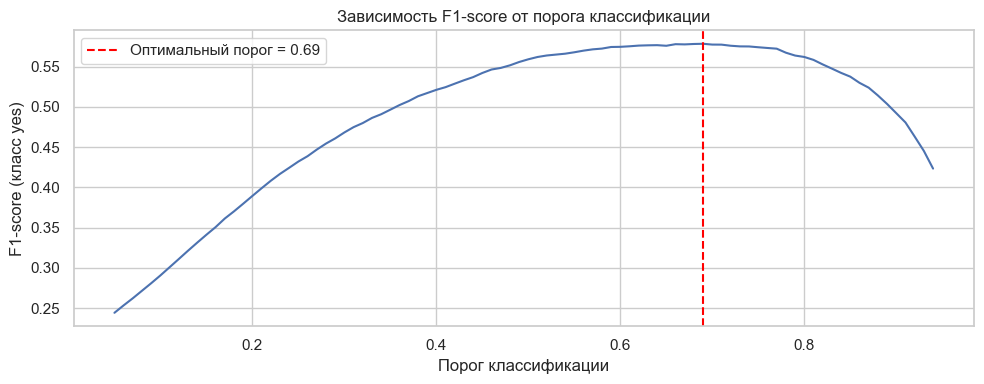

In [5]:
thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores_thresh = [f1_score(y, (y_proba_oof >= t).astype(int)) for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores_thresh)]
y_pred_opt = (y_proba_oof >= best_threshold).astype(int)

print(f"Оптимальный порог: {best_threshold:.2f}")
print(f"F1-score при пороге 0.50: {f1:.4f}")
print(f"F1-score при оптимальном пороге: {f1_score(y, y_pred_opt):.4f}")
print()
print(classification_report(y, y_pred_opt, target_names=['no', 'yes']))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, f1_scores_thresh)
ax.axvline(best_threshold, color='red', linestyle='--', label=f'Оптимальный порог = {best_threshold:.2f}')
ax.set_xlabel('Порог классификации')
ax.set_ylabel('F1-score (класс yes)')
ax.set_title('Зависимость F1-score от порога классификации')
ax.legend()
plt.tight_layout()
plt.show()

## 1.8. ROC-кривая и матрица ошибок при оптимальном пороге

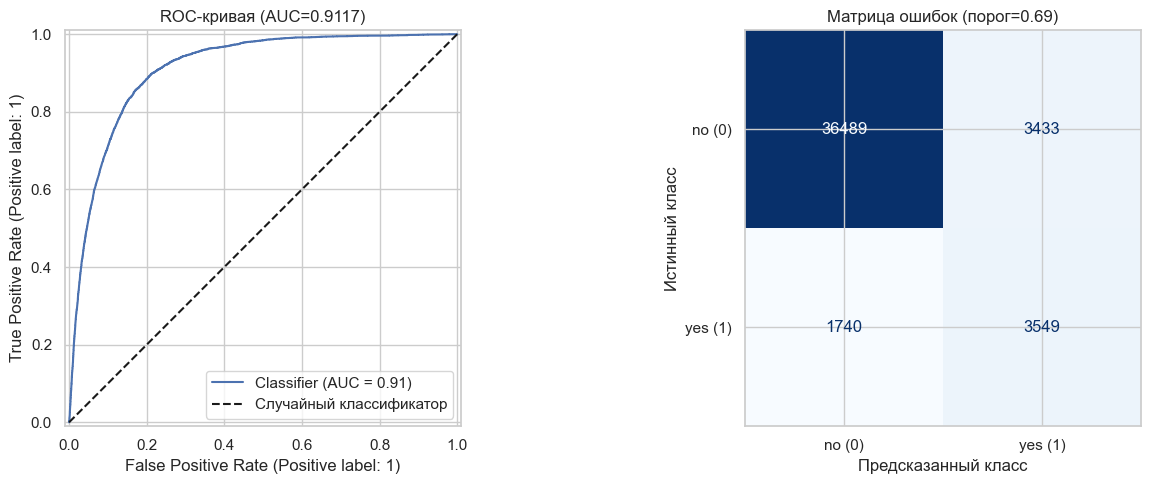

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(y, y_proba_oof, ax=axes[0])
axes[0].plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
axes[0].set_title(f'ROC-кривая (AUC={roc_auc:.4f})')
axes[0].legend()

ConfusionMatrixDisplay.from_predictions(
    y, y_pred_opt,
    display_labels=['no (0)', 'yes (1)'],
    cmap='Blues',
    colorbar=False,
    ax=axes[1]
)
axes[1].set_title(f'Матрица ошибок (порог={best_threshold:.2f})')
axes[1].set_xlabel('Предсказанный класс')
axes[1].set_ylabel('Истинный класс')

plt.tight_layout()
plt.show()

## 1.9. Анализ коэффициентов модели

Коэффициенты логистической регрессии характеризуют вклад каждого признака в логит-вероятность принадлежности к классу «yes». Положительное значение увеличивает вероятность отклика, отрицательное — уменьшает.

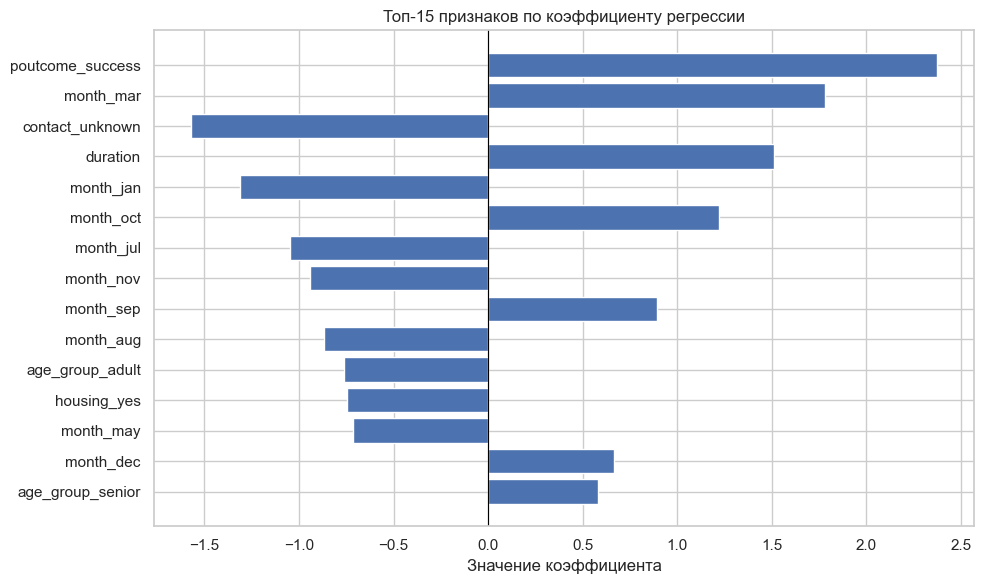

In [7]:
best_model.fit(X, y)
coef_df = pd.DataFrame({'feature': X.columns, 'coef': best_model.coef_[0]})
coef_df = coef_df.reindex(coef_df['coef'].abs().sort_values(ascending=False).index).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(coef_df['feature'], coef_df['coef'])
ax.axvline(0, color='black', lw=0.8)
ax.invert_yaxis()
ax.set_title('Топ-15 признаков по коэффициенту регрессии')
ax.set_xlabel('Значение коэффициента')
plt.tight_layout()
plt.show()

## 1.10. Выводы

По результатам проверки гипотезы 1 установлено следующее:

1. Оптимальные гиперпараметры (`C=0.1`, `class_weight='balanced'`, `penalty='l2'`) определены методом полного перебора с 5-кратной стратифицированной кросс-валидацией.
2. Оптимизация порога классификации улучшает F1-score для класса «yes» по сравнению со стандартным порогом 0.5.
3. Логистическая регрессия формирует **базовый уровень качества**: как линейная модель она уступает ансамблевым методам (H2–H3) в задачах с нелинейными зависимостями, однако обеспечивает хорошую интерпретируемость коэффициентов.
4. Признаки `duration` и `poutcome_success` обладают наибольшей предсказательной силой, что совпадает с выводами EDA.